# Notebook 4 — SOLUTION

## Short version

**These neurons carry no block information at all.** `dataset_1` is pure slow
**drift** -- temporally smoothed noise, generated completely independently of the
block. The ~95% is an artifact of combining two slow signals:

- the **block** is slow (constant for 30-70 trials), and
- the **neural activity drifts** slowly over the session.

Ordinary k-fold CV shuffles trials into folds, so each held-out trial is
surrounded in time by *training* trials from the **same block** in a **similar
drift state**. The decoder just reads the drift and interpolates -- it never
needs to encode the block.

The rest of this notebook shows three things: (1) the correct controls
(leave-one-block-out CV and a pseudosession null) that expose the artifact,
(2) a positive control (`dataset_2`) where the block really is encoded, and
(3) an advanced section on how these controls can *themselves* fail.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold, cross_val_predict

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

def make_blocks(rng, n_trials=None, n_blocks=10, lo=30, hi=70, fixed=None):
    """Alternating +/-1 blocks, uniform-random lengths (lo..hi), random start
    sign. Pass n_trials to fill/truncate to exactly that many trials (handy for
    making pseudosessions); otherwise returns n_blocks blocks and their ids."""
    sign = rng.choice([-1, 1]); values, ids, i = [], [], 0
    if n_trials is None:
        lengths = [fixed]*n_blocks if fixed else rng.integers(lo, hi+1, size=n_blocks)
        for i, L in enumerate(lengths):
            values += [sign*(-1)**i]*int(L); ids += [i]*int(L)
        return np.array(values), np.array(ids)
    while len(values) < n_trials:
        L = fixed if fixed else rng.integers(lo, hi+1)
        values += [sign*(-1)**i]*int(L); i += 1
    return np.array(values[:n_trials]), None

def trialwise_cv(X, y, folds=10, seed=0):
    """Ordinary k-fold CV over trials (trials are shuffled into folds)."""
    kf = KFold(folds, shuffle=True, random_state=seed)
    return np.mean([LinearDiscriminantAnalysis().fit(X[tr], y[tr]).score(X[te], y[te])
                    for tr, te in kf.split(X)])

def blockout_cv(X, y, block_ids):
    """Leave-one-block-out CV: hold out each whole block in turn."""
    return np.array([LinearDiscriminantAnalysis().fit(X[block_ids != b], y[block_ids != b])
                     .score(X[block_ids == b], y[block_ids == b])
                     for b in np.unique(block_ids)])

def pseudo_null(X, n_trials, rng, n=150, fixed=None, folds=5):
    """Trial-wise decoding accuracy for many surrogate ('pseudo') block
    sequences with the same statistics but independent of the neural data."""
    return np.array([trialwise_cv(X, make_blocks(rng, n_trials=n_trials, fixed=fixed)[0],
                                  folds=folds, seed=1) for _ in range(n)])


In [2]:
d = np.load('data/dataset_1.npz')
activity = d['activity']; block_values = d['block_values']; block_ids = d['block_ids']
X = activity.T; y = block_values
n_neurons, n_trials = activity.shape
print(f'trial-wise CV accuracy: {trialwise_cv(X, y)*100:.1f}%  (looks like strong coding)')


trial-wise CV accuracy: 97.7%  (looks like strong coding)


## Evidence 1 — Leave-one-block-out CV

Hold out an entire block at a time (so no trial from the held-out block, and
none of its drift state, is in training). Now the decoder has nothing to
interpolate from, and performance collapses to chance.


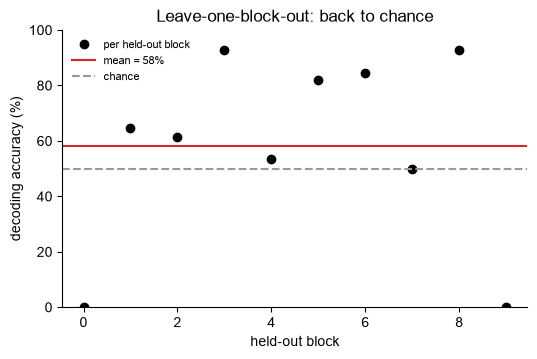

trial-wise CV: 97.7%   leave-block-out CV: 58.1%


In [3]:
block_acc = blockout_cv(X, y, block_ids)     # one accuracy per held-out block

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(np.unique(block_ids), block_acc*100, 'o', color='k', label='per held-out block')
ax.axhline(np.mean(block_acc)*100, color='tab:red', label=f'mean = {np.mean(block_acc)*100:.0f}%')
ax.axhline(50, color='0.6', ls='--', label='chance')
ax.set_xlabel('held-out block'); ax.set_ylabel('decoding accuracy (%)')
ax.set_ylim(0, 100); ax.set_title('Leave-one-block-out: back to chance')
ax.legend(frameon=False, fontsize=8)
plt.show()
print(f'trial-wise CV: {trialwise_cv(X, y)*100:.1f}%   leave-block-out CV: {np.mean(block_acc)*100:.1f}%')


## Evidence 2 — The mechanism: slow drift

The activity drifts slowly over the session, independently of the block. Because
the block is *also* slow, ordinary CV's held-out trials sit next to same-block
training trials at nearly the same drift state -- so the out-of-fold decoder
output tracks the block even though nothing encodes it.


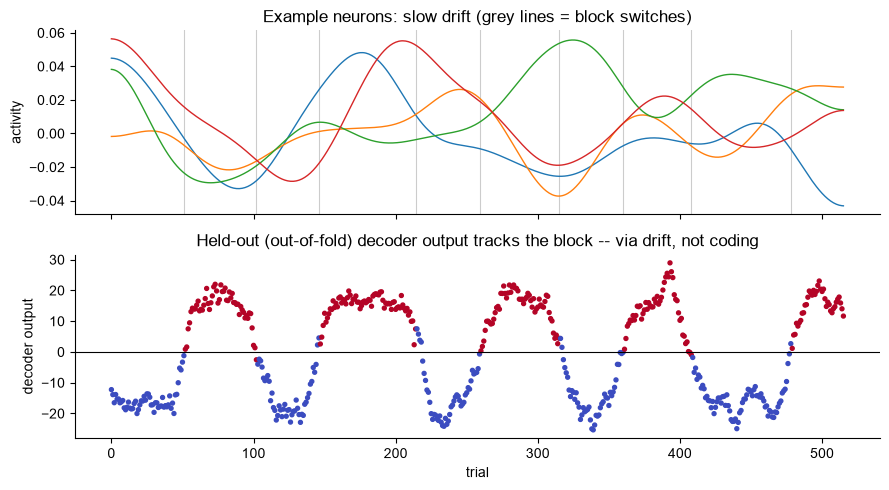

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
# a few example neurons: slow drift, unrelated to the block boundaries
for i in range(4):
    axes[0].plot(activity[i], lw=1)
for b in np.where(np.diff(block_values) != 0)[0]:
    axes[0].axvline(b, color='0.8', lw=0.8, zorder=0)
axes[0].set_ylabel('activity'); axes[0].set_title('Example neurons: slow drift (grey lines = block switches)')

# out-of-fold decoder output from ordinary k-fold CV, colored by true block
proj = cross_val_predict(LinearDiscriminantAnalysis(), X, y,
                         cv=KFold(10, shuffle=True, random_state=0),
                         method='decision_function')
axes[1].scatter(np.arange(n_trials), proj, c=block_values, cmap='coolwarm', s=8)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('trial'); axes[1].set_ylabel('decoder output')
axes[1].set_title('Held-out (out-of-fold) decoder output tracks the block -- via drift, not coding')
plt.tight_layout(); plt.show()


## Evidence 3 — A pseudosession null

Keep trial-wise CV, but ask the right question: is 95% more than you'd get for
*any* slow block-like sequence? Generate many **pseudosessions** -- surrogate
block sequences with the same statistics but independent of the neurons -- and
decode each. Slow drift decodes a slow surrogate about as well as the real
block, so the real accuracy sits right inside the null: no evidence of coding.


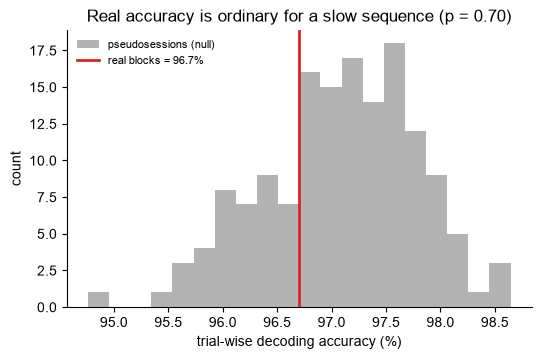

In [5]:
rng = np.random.default_rng(0)
null = pseudo_null(X, n_trials, rng, n=150)      # trial-wise acc for pseudo sequences
real = trialwise_cv(X, y, folds=5)
pval = (np.sum(null >= real) + 1) / (len(null) + 1)

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(null*100, bins=20, color='0.7', label='pseudosessions (null)')
ax.axvline(real*100, color='tab:red', lw=2, label=f'real blocks = {real*100:.1f}%')
ax.set_xlabel('trial-wise decoding accuracy (%)'); ax.set_ylabel('count')
ax.set_title(f'Real accuracy is ordinary for a slow sequence (p = {pval:.2f})')
ax.legend(frameon=False, fontsize=8)
plt.show()


## Positive control — `dataset_2`, where the block really is encoded

Same task, a population that genuinely carries a block signal (and no drift).
Now all three analyses agree: trial-wise CV, leave-block-out CV, and the
pseudosession test all say "coding".


In [6]:
d2 = np.load('data/dataset_2.npz')
X2 = d2['activity'].T; y2 = d2['block_values']; ids2 = d2['block_ids']
rng = np.random.default_rng(1)
null2 = pseudo_null(X2, len(y2), rng, n=150)
real2 = trialwise_cv(X2, y2, folds=5)
print(f'trial-wise CV      : {trialwise_cv(X2, y2)*100:.1f}%')
print(f'leave-block-out CV : {np.mean(blockout_cv(X2, y2, ids2))*100:.1f}%')
print(f'pseudosession null : mean {null2.mean()*100:.1f}%, real {real2*100:.1f}%, '
      f'p = {(np.sum(null2>=real2)+1)/(len(null2)+1):.3f}')


trial-wise CV      : 100.0%


leave-block-out CV : 100.0%
pseudosession null : mean 61.3%, real 100.0%, p = 0.007


# Advanced — the controls are not silver bullets

Leave-block-out CV and pseudosessions fix the false *positive* from drift. But
under strong drift they become **conservative** and can miss real coding (false
*negatives*), and pseudosessions have a design prerequisite.


## Weak coding under strong drift

Simulate a population that *does* encode the block, but weakly, on top of drift
that gets progressively stronger. Trial-wise CV stays pinned at ~100% (useless).
Leave-block-out CV stays high while the signal is detectable, then finally
collapses below chance when drift overwhelms it -- a false negative. Projecting
onto the *true* (oracle) coding weights shows the signal is still there.


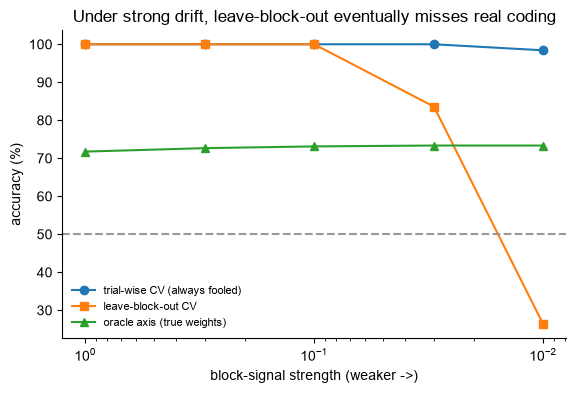

signal=1.0  : leave-block-out= 100%   oracle=  72%
signal=0.3  : leave-block-out= 100%   oracle=  73%
signal=0.1  : leave-block-out= 100%   oracle=  73%
signal=0.03 : leave-block-out=  84%   oracle=  73%
signal=0.01 : leave-block-out=  26%   oracle=  73%


In [7]:
def simulate(rng, blocks, signal_scale, drift_scale, n_neurons=100, noise=0.2, drift_sigma=25):
    nT = len(blocks)
    w = rng.uniform(-0.5, 0.5, n_neurons) * signal_scale          # weak block weights
    drift = gaussian_filter1d(rng.normal(0, 1, (n_neurons, nT))*noise, drift_sigma, axis=1)
    return (np.outer(w, blocks) + drift*drift_scale).T, w

signal_scales = [1.0, 0.3, 0.1, 0.03, 0.01]
tw_acc, bo_acc, oracle_acc = [], [], []
for s in signal_scales:
    rng = np.random.default_rng(0)
    blocks, ids = make_blocks(rng)
    Xw, w = simulate(rng, blocks, signal_scale=s, drift_scale=3000)
    tw_acc.append(trialwise_cv(Xw, blocks))
    bo_acc.append(np.mean(blockout_cv(Xw, blocks, ids)))
    proj = Xw @ w                                                  # oracle: true weights
    oracle_acc.append(max(np.mean((proj > 0) == (blocks > 0)),
                          np.mean((proj < 0) == (blocks > 0))))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(signal_scales, np.array(tw_acc)*100, 'o-', label='trial-wise CV (always fooled)')
ax.plot(signal_scales, np.array(bo_acc)*100, 's-', label='leave-block-out CV')
ax.plot(signal_scales, np.array(oracle_acc)*100, '^-', color='tab:green',
        label='oracle axis (true weights)')
ax.axhline(50, color='0.6', ls='--')
ax.set_xscale('log'); ax.invert_xaxis()
ax.set_xlabel('block-signal strength (weaker ->)'); ax.set_ylabel('accuracy (%)')
ax.set_title('Under strong drift, leave-block-out eventually misses real coding')
ax.legend(frameon=False, fontsize=8)
plt.show()
for s, b, o in zip(signal_scales, bo_acc, oracle_acc):
    print(f'signal={s:<5}: leave-block-out={b*100:4.0f}%   oracle={o*100:4.0f}%')


## Why the block *design* matters for pseudosessions

Pseudosessions need a pool of surrogate sequences that share the block
statistics but land in *different places*. That requires **randomized block
lengths**. If every block were a fixed length (say exactly 50 trials), every
surrogate would have its boundaries at the same trials -- only the start sign
could differ -- so the "null" has essentially no spread and can't calibrate
anything. Randomized lengths give a real null; fixed lengths break the method.


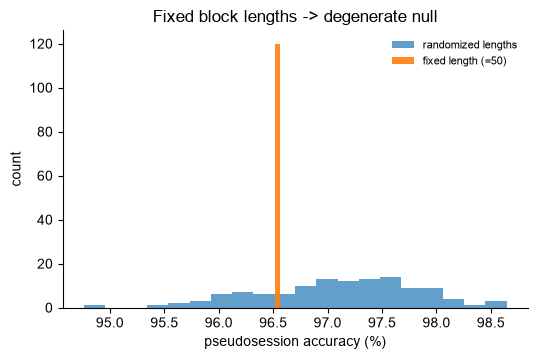

randomized lengths: null std = 0.72%, 18 distinct values
fixed length      : null std = 0.00%, 1 distinct values


In [8]:
rng = np.random.default_rng(0)
null_random = pseudo_null(X, n_trials, rng, n=120, fixed=None)   # randomized lengths
null_fixed  = pseudo_null(X, n_trials, rng, n=120, fixed=50)     # every block = 50 trials

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(null_random*100, bins=20, color='tab:blue', alpha=0.7, label='randomized lengths')
ax.hist(null_fixed*100,  bins=20, color='tab:orange', alpha=0.9, label='fixed length (=50)')
ax.set_xlabel('pseudosession accuracy (%)'); ax.set_ylabel('count')
ax.set_title('Fixed block lengths -> degenerate null')
ax.legend(frameon=False, fontsize=8)
plt.show()
print(f'randomized lengths: null std = {null_random.std()*100:.2f}%, '
      f'{len(np.unique(np.round(null_random,3)))} distinct values')
print(f'fixed length      : null std = {null_fixed.std()*100:.2f}%, '
      f'{len(np.unique(np.round(null_fixed,3)))} distinct values')


## The lesson

- **Cross-validation is not automatically valid.** Ordinary k-fold CV assumes
  held-out samples are independent of the training set. For a *slowly-varying*
  target (a block variable) measured from data with *slow drift*, that
  assumption fails: adjacent trials share both block and drift state, so the
  decoder reads the drift and reports high "accuracy" for a variable it does not
  encode.
- **Match the control to the structure.** Hold out contiguous **blocks**, not
  scattered trials; or compare against a **pseudosession null** that preserves
  the slow temporal structure of the variable. Either exposes the drift artifact.
- **The controls are conservative, not infallible.** Under strong drift they can
  miss weak-but-real coding (a false negative), and pseudosessions require
  randomized block lengths to have any power at all. Report effect sizes and,
  where possible, validate on an independent recording.
